In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.calibration import CalibrationDisplay



In [53]:
X_train = pd.read_csv("X_train.csv", index_col=0)
X_test  = pd.read_csv("X_test.csv", index_col=0)
y_train = pd.read_csv("y_train.csv", index_col=0).iloc[:,0]
y_test  = pd.read_csv("y_test.csv", index_col=0).iloc[:,0]

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((609, 32),
 (153, 32),
 DESERTA
 0    527
 1     82
 Name: count, dtype: int64,
 DESERTA
 0    133
 1     20
 Name: count, dtype: int64)

In [55]:
# Fuerza categóricas a string para OHE robusto
X_train = X_train.apply(lambda s: s.astype(str))
X_test  = X_test.apply(lambda s: s.astype(str))

cat_cols = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop"
)

In [56]:
logreg_l1 = LogisticRegression(
    penalty="l1", solver="liblinear",
    C=0.1,                 # puedes afinar luego (0.03–0.3)
    class_weight="balanced",
    max_iter=5000
)

pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", logreg_l1)
])

pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
proba_test = pipe.predict_proba(X_test)[:,1]
pred_test  = (proba_test >= 0.5).astype(int)

In [58]:
cm = confusion_matrix(y_test, pred_test, labels=[0,1])
cm_df = pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Pred 0", "Pred 1"])
print("\nMatriz de confusión (frecuencia absoluta):")
display(cm_df)


Matriz de confusión (frecuencia absoluta):


,Pred 0,Pred 1
Real 0,124,9
Real 1,4,16


In [59]:
cm_pct = (cm / cm.sum()) * 100.0          # % sobre el total de observaciones
cm_pct_df = pd.DataFrame(np.round(cm_pct, 2),
                         index=["Real 0", "Real 1"],
                         columns=["Pred 0", "Pred 1"])
print("\nMatriz de confusión (frecuencia relativa % del total):")
display(cm_pct_df)


Matriz de confusión (frecuencia relativa % del total):


,Pred 0,Pred 1
Real 0,81.05,5.88
Real 1,2.61,10.46


In [60]:
print(classification_report(y_test, pred_test, digits=3, target_names=["No deserta (0)", "Deserta (1)"]))

                precision    recall  f1-score   support

No deserta (0)      0.969     0.932     0.950       133
   Deserta (1)      0.640     0.800     0.711        20

      accuracy                          0.915       153
     macro avg      0.804     0.866     0.831       153
  weighted avg      0.926     0.915     0.919       153



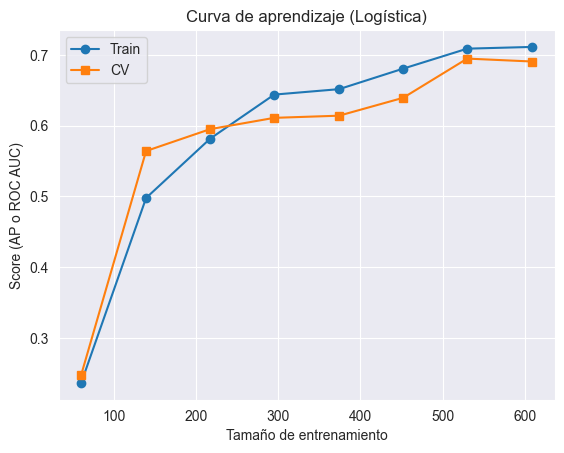

In [61]:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipe,              # tu Pipeline (prep + logística)
    X=X, y=y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv,
    scoring="average_precision", # o "roc_auc"
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Train")
plt.plot(train_sizes, val_mean, marker="s", label="CV")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("Score (AP o ROC AUC)")
plt.title("Curva de aprendizaje (Logística)")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_cv = cross_val_score(pipe, X, y, scoring="roc_auc", cv=cv, n_jobs=-1)
print("ROC AUC CV:", np.round(auc_cv,3), "→ media:", auc_cv.mean().round(3))


ROC AUC CV: [0.953 0.953 0.924 0.889 0.947] → media: 0.933


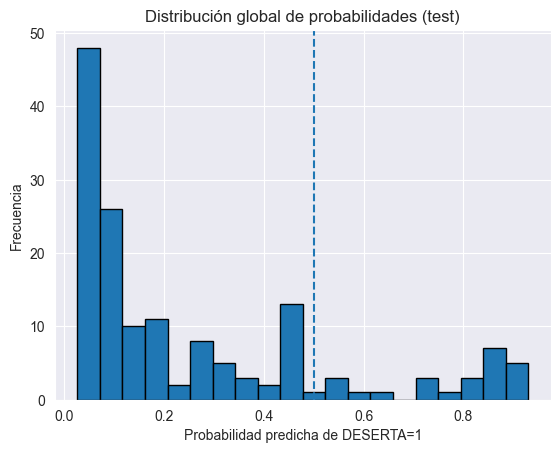

{'min': np.float64(0.026), 'p10': np.float64(0.029), 'p25': np.float64(0.057), 'p50': np.float64(0.129), 'p75': np.float64(0.41), 'p90': np.float64(0.77), 'max': np.float64(0.93)}


In [64]:
plt.figure()
plt.hist(proba_test, bins=20, edgecolor="black")
plt.axvline(0.5, linestyle="--")  # umbral 0.5 (ajústalo si usas otro)
plt.xlabel("Probabilidad predicha de DESERTA=1")
plt.ylabel("Frecuencia")
plt.title("Distribución global de probabilidades (test)")
plt.show()

# Resumen rápido
q = np.quantile(proba_test, [0, .1, .25, .5, .75, .9, 1])
print(dict(zip(["min","p10","p25","p50","p75","p90","max"], np.round(q,3))))

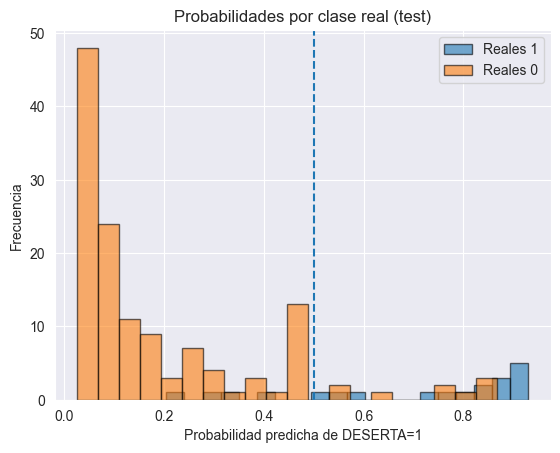

In [65]:
mask1 = (y_test == 1)
mask0 = ~mask1

plt.figure()
plt.hist(proba_test[mask1], bins=20, alpha=0.6, label="Reales 1", edgecolor="black")
plt.hist(proba_test[mask0], bins=20, alpha=0.6, label="Reales 0", edgecolor="black")
plt.axvline(0.5, linestyle="--")
plt.xlabel("Probabilidad predicha de DESERTA=1")
plt.ylabel("Frecuencia")
plt.title("Probabilidades por clase real (test)")
plt.legend()
plt.show()

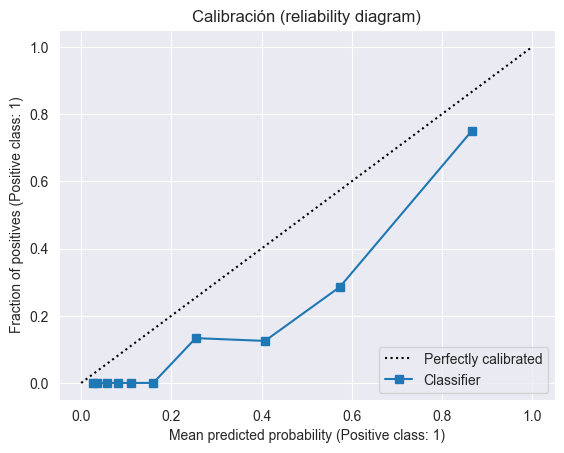

In [66]:
CalibrationDisplay.from_predictions(y_test, proba_test, n_bins=10, strategy="quantile")
plt.title("Calibración (reliability diagram)")
plt.show()

In [68]:
fpr, tpr, thr = roc_curve(y_test, proba_test)
youden = tpr - fpr
best_thr = thr[np.argmax(youden)]
best_thr

np.float64(0.5222432091276815)

In [69]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

# Toma tu pipeline actual: ("prep", preprocessor), ("clf", LogisticRegression(...))
base = pipe

pipe_cal = Pipeline([
    ("prep", preprocessor),
    ("cal", CalibratedClassifierCV(
        base.named_steps["clf"], method="isotonic", cv=5   # o method="sigmoid" (Platt)
    ))
])
pipe_cal.fit(X_train, y_train)

# Evalúa de nuevo:
from sklearn.metrics import brier_score_loss, average_precision_score
proba_cal = pipe_cal.predict_proba(X_test)[:,1]
print("Brier:", brier_score_loss(y_test, proba_cal))
print("PR-AUC:", average_precision_score(y_test, proba_cal))

Brier: 0.06113757780090214
PR-AUC: 0.7384572167929937


In [70]:
proba = pipe_cal.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, proba)
thr = np.r_[0.0, thr]

In [71]:
def fbeta(p, r, beta=1.0):
    b2 = beta**2
    den = b2*p + r
    return (1 + b2) * p * r / np.where(den==0, np.inf, den)

In [52]:
# CSV (recomendado, legible)
X_train.to_csv("X_train.csv", index=True, encoding="utf-8-sig")
X_test.to_csv("X_test.csv", index=True, encoding="utf-8-sig")
y_train.to_csv("y_train.csv", index=True, header=True, encoding="utf-8-sig")
y_test.to_csv("y_test.csv", index=True, header=True, encoding="utf-8-sig")